## WorldView Scene-Combination Benchmark: SpaceNet Atlanta

**Given N same-pass scenes, which combinations and which processing flow give the best DEM?** This notebook is the systematic version of the two-DEM comparison in [`worldview_spacenet_atlanta_mvs.ipynb`](https://asp-plot.readthedocs.io/en/latest/examples/notebooks/worldview_spacenet_atlanta_mvs.html) ([issue #169](https://github.com/uw-cryo/asp_plot/issues/169)). Everything is scored with `asp_plot.dem_benchmark.DEMBenchmark` against **one** ICESat-2 ATL06-SR sample, so every number below is directly comparable.

Three questions, three axes of the experiment:

1. **Convergence angle** — all ten pairs among the five scenes span 5–32°. How does single-pair accuracy depend on it, and where does the pair-selection rule of thumb (20–30°) sit on this data?
2. **Number of scenes** — a nested chain, pair 13-10 ⊂ MVS {13,10,16} ⊂ MVS {13,10,16,21} ⊂ MVS {all five}: does each added scene earn its cost?
3. **Processing flow** — joint multi-view triangulation vs. independent pairs merged with `dem_mosaic`, at three and at five scenes; and whether merging only the well-converged pairs rescues the mosaic.

> **Status.** The runs are produced by [`run_benchmark.sh`](run_benchmark.sh) next to this notebook (~11–12 h on a laptop; see the *Processing* section). The scoring cells score **whatever DEMs exist on disk** and list the rest as pending, so the notebook is valid at every stage — as committed it covers the six DEMs from the MVS example (three pairs, their mosaic, and the 3- and 5-scene MVS runs).

---

## Testbed

Five same-pass WorldView-2 scenes over Hartsfield–Jackson Atlanta International Airport (2009-12-22, SpaceNet AOI 6, public on `s3://spacenet-dataset/AOIs/AOI_6_Atlanta/`), all `wv_correct`ed and bundle-adjusted **together** (`ba/run`, five scenes), so every stereo run below shares one camera network and any DEM difference comes from the stereo strategy, not the cameras. See the MVS notebook for the download, `wv_correct`, and `bundle_adjust` steps.

| Name | CATID / tile | Along-track order | Role |
|---|---|---|---|
| nadir10 | `1030010003CAF100_P002` | 1 | |
| nadir8 | `10300100023BC100_P001` | 2 | |
| nadir13 | `1030010002B7D800_P002` | 3 | reference scene of every MVS run (crop window `5879 13107 12981 11894`) |
| nadir16 | `1030010002649200_P001` | 4 | |
| nadir21 | `1030010003127500_P001` | 5 | |

`bundle_adjust` reports the convergence angle of every image pair that had matches, which is the first axis of the experiment:

In [1]:
import os

import numpy as np
import pandas as pd

# Set the base directory for your processing
directory = "~/Desktop/asp-plot-examples/atlanta_mvs/"
directory = os.path.expanduser(directory)

SCENES = {
    "1030010003CAF100_P002": "10",
    "10300100023BC100_P001": "8",
    "1030010002B7D800_P002": "13",
    "1030010002649200_P001": "16",
    "1030010003127500_P001": "21",
}

# ba/run-convergence_angles.txt: left right 25% 50% 75% num_matches (degrees)
conv = pd.read_csv(
    f"{directory}ba/run-convergence_angles.txt",
    sep=r"\s+",
    comment="#",
    names=["left", "right", "p25", "p50", "p75", "num_matches"],
)
for col in ("left", "right"):
    conv[col] = conv[col].str.replace("_corr.tif", "", regex=False).map(SCENES)


def pair_dir(a, b):
    """stereo_pair_<A>_<B> as produced by run_pairwise.sh / run_benchmark.sh (either order)."""
    for left, right in ((a, b), (b, a)):
        d = f"stereo_pair_{left}_{right}"
        if os.path.isdir(f"{directory}{d}"):
            return d
    return f"stereo_pair_{a}_{b}"


conv["pair"] = conv.apply(lambda r: f"{r.left}-{r.right}", axis=1)
conv["run_dir"] = conv.apply(lambda r: pair_dir(r.left, r.right), axis=1)
conv["dem_exists"] = conv["run_dir"].map(lambda d: os.path.exists(f"{directory}{d}/run-DEM.tif"))
conv = conv.sort_values("p50").reset_index(drop=True)
conv[["pair", "p50", "p25", "p75", "num_matches", "run_dir", "dem_exists"]].rename(
    columns={"p50": "convergence (deg)"}
)

,pair,convergence (deg),p25,p75,num_matches,run_dir,dem_exists
0,13-16,5.123524,4.831792,5.479853,7451,stereo_pair_13_16,True
1,16-21,5.361678,5.327280,5.394798,6201,stereo_pair_16_21,False
2,8-10,5.456345,5.099122,5.876843,7305,stereo_pair_8_10,False
3,13-21,10.507380,10.241351,10.817621,4813,stereo_pair_13_21,False
4,13-8,16.325202,15.900078,16.673266,5550,stereo_pair_13_8,False
5,8-16,21.465489,21.401535,21.518222,3707,stereo_pair_8_16,False
6,13-10,21.791530,21.786859,21.795557,4725,stereo_pair_13_10,True
7,8-21,26.834443,26.725781,26.920276,2188,stereo_pair_8_21,False
8,10-16,26.934903,26.626338,27.294847,2822,stereo_pair_10_16,True
9,10-21,32.293319,32.017714,32.622930,1860,stereo_pair_10_21,False


Ten pairs, evenly spread from 5° to 32°, with three of them already run for the MVS example (5.1°, 21.8°, 26.9°). The match count falls with convergence, as expected for the same interest-point detector seeing an increasingly different view.

### Crop windows for the new pairs

Every existing run crops the reference scene (nadir13) to the airport window and lets ASP find the corresponding region in the other image. A pair whose *left* image is not nadir13 needs its own `--left-image-crop-win`, which is derived the same way `run_pairwise.sh` derived nadir10's: take the `bundle_adjust` clean match points between nadir13 and that scene, keep those inside the nadir13 crop, and pad the bounding box of their partners by 100 px. nadir10's window reproduces the one used for `stereo_pair_10_16`, which validates the method; the other three are what `run_benchmark.sh` uses.

In [2]:
from asp_plot.stereo import StereoPlotter

XOFF, YOFF, W, H = 5879, 13107, 12981, 11894  # nadir13 reference crop
REF = "1030010002B7D800_P002"

stereo_plotter = StereoPlotter(directory, "stereo_mvs3")
crops = {"13": (XOFF, YOFF, W, H)}
for cid, name in SCENES.items():
    if cid == REF:
        continue
    match_fn = f"{directory}ba/run-{REF}_corr__{cid}_corr-clean.match"
    match_df = stereo_plotter.get_match_point_df(match_point_fn=match_fn)
    inwin = match_df[match_df.x1.between(XOFF, XOFF + W) & match_df.y1.between(YOFF, YOFF + H)]
    pad = 100
    x0, y0 = int(inwin.x2.min()) - pad, int(inwin.y2.min()) - pad
    x1, y1 = int(inwin.x2.max()) + pad, int(inwin.y2.max()) + pad
    crops[name] = (x0, y0, x1 - x0, y1 - y0)
    print(
        f"nadir{name:<3} {len(inwin):5d} of {len(match_df):5d} clean matches in the reference crop"
        f"  -> --left-image-crop-win {x0} {y0} {x1 - x0} {y1 - y0}"
    )


No reference DEM found in log files. Please supply the reference DEM you used during stereo processing (or another reference DEM) if you would like to see some difference maps.





ASP DEM: /Users/ben/Desktop/asp-plot-examples/atlanta_mvs/stereo_mvs3/run-DEM.tif

nadir10    775 of  4725 clean matches in the reference crop  -> --left-image-crop-win 5540 13223 13206 12931
nadir8     890 of  5550 clean matches in the reference crop  -> --left-image-crop-win 5461 9789 13354 12980
nadir16   1176 of  7451 clean matches in the reference crop  -> --left-image-crop-win 6083 8756 12879 11461
nadir21    785 of  4813 clean matches in the reference crop  -> --left-image-crop-win 6467 8177 12495 10687


---

## Processing

[`run_benchmark.sh`](run_benchmark.sh) runs everything the matrix needs that the MVS example did not, with the settings of the existing runs (`asp_mgm`, `--subpixel-mode 9`, `affineepipolar`, the shared `ba/run` prefix, `point2dem --tr 1.9 --t_srs EPSG:32616 --errorimage`). Every step is skipped when its product exists, so it can be re-run after an interruption:

```bash
$ bash notebooks/WorldView/run_benchmark.sh ~/Desktop/asp-plot-examples/atlanta_mvs
```

| Step | Products | Answers |
|---|---|---|
| `wv_correct` × 5 | `<catid>_corr.tif` | (the intermediates were purged after the earlier runs) |
| the seven remaining pairs | `stereo_pair_13_8`, `_13_21`, `_10_8`, `_10_21`, `_8_16`, `_8_21`, `_16_21` | axis 1: NMAD vs. convergence over all ten pairs |
| `dem_mosaic` of all ten pairs / of the six pairs > 15° | `pairwise10_mosaic-DEM.tif`, `pairwise_wide6_mosaic-DEM.tif` | axis 3: the five-scene pairwise flows |
| nested quad `{13,10,16,21}` | `stereo_mvs4/` | axis 2: the 2→3→4→5 chain |
| wide-spread triple `{13,8,21}` | `stereo_mvs3_wide/` | axis 2/3: does the *choice* of three scenes matter as much as their number? |

About 11–12 hours on an 8-thread laptop (pair ≈ 1 h, triple ≈ 2 h, quad ≈ 2.5 h) and ~30 GB.

---

## Scoring every DEM against one ICESat-2 sample

`DEMBenchmark` scores each candidate with the report's recipe — the cached ATL06-SR parquet replayed (no SlideRule request), ESA WorldCover water returns dropped, a 3σ outlier cut per DEM — and a `pc_align --compute-translation-only` of its own, whose products go under `dem_benchmark/<label>/`. Coverage and triangulation error are measured inside the **common footprint** of all the DEMs scored. The candidate list below is the full matrix; DEMs that have not been produced yet are reported as pending and the rest are scored.

In [3]:
from asp_plot.dem_benchmark import DEMBenchmark

conv_of = dict(zip(conv["pair"], conv["p50"]))

candidates = {}
for _, r in conv.iterrows():
    candidates[f"pair {r.pair} ({r.p50:.1f}°)"] = f"{directory}{r.run_dir}/run-DEM.tif"
candidates.update(
    {
        "3 pairs + mosaic {13,10,16}": f"{directory}pairwise_mosaic-DEM.tif",
        "6 pairs > 15° + mosaic": f"{directory}pairwise_wide6_mosaic-DEM.tif",
        "10 pairs + mosaic": f"{directory}pairwise10_mosaic-DEM.tif",
        "MVS 3 {13,10,16}": f"{directory}stereo_mvs3/run-DEM.tif",
        "MVS 3 {13,8,21}": f"{directory}stereo_mvs3_wide/run-DEM.tif",
        "MVS 4 {13,10,16,21}": f"{directory}stereo_mvs4/run-DEM.tif",
        "MVS 5": f"{directory}stereo_mvs5/run-DEM.tif",
    }
)

existing = {k: v for k, v in candidates.items() if os.path.exists(v)}
pending = [k for k in candidates if k not in existing]
print(f"{len(existing)} of {len(candidates)} candidates on disk; pending: {pending}\n")

bench = DEMBenchmark(
    directory=directory,
    dems=existing,
    parquet=f"{directory}atl06sr_all.parquet",
    reference="MVS 5",
    title="Atlanta WV2 2009-12-22: same-pass scene combinations",
)
stats = bench.run()
stats.drop(columns=["dem_fn", "gsd_m", "north_shift_m", "east_shift_m", "down_shift_m"]).round(2)

6 of 17 candidates on disk; pending: ['pair 16-21 (5.4°)', 'pair 8-10 (5.5°)', 'pair 13-21 (10.5°)', 'pair 13-8 (16.3°)', 'pair 8-16 (21.5°)', 'pair 8-21 (26.8°)', 'pair 10-21 (32.3°)', '6 pairs > 15° + mosaic', '10 pairs + mosaic', 'MVS 3 {13,8,21}', 'MVS 4 {13,10,16,21}']


=== [1/6] pair 13-16 (5.1°): /Users/ben/Desktop/asp-plot-examples/atlanta_mvs/stereo_pair_13_16/run-DEM.tif


Reusing ICESat-2 ATL06-SR points for 'all' from: /Users/ben/Desktop/asp-plot-examples/atlanta_mvs/atl06sr_all.parquet
Filtering ATL06-SR all


  Outlier filter (3σ): all 7937 → 7779 (removed 158)
  7013 altimetry points: median +0.49 m, NMAD 1.54 m
  Reusing pc_align output in /Users/ben/Desktop/asp-plot-examples/atlanta_mvs/dem_benchmark/pair_13-16_5.1/pc_align



Writing out: /Users/ben/Desktop/asp-plot-examples/atlanta_mvs/dem_benchmark/pair_13-16_5.1/run-DEM_pc_align_translated.tif



  after pc_align (|t| = 0.63 m): median +0.27 m, NMAD 1.54 m


...


=== [6/6] MVS 5: /Users/ben/Desktop/asp-plot-examples/atlanta_mvs/stereo_mvs5/run-DEM.tif


Reusing ICESat-2 ATL06-SR points for 'all' from: /Users/ben/Desktop/asp-plot-examples/atlanta_mvs/atl06sr_all.parquet
Filtering ATL06-SR all


  Outlier filter (3σ): all 7937 → 7756 (removed 181)
  7043 altimetry points: median +0.12 m, NMAD 0.68 m
  Reusing pc_align output in /Users/ben/Desktop/asp-plot-examples/atlanta_mvs/dem_benchmark/MVS_5/pc_align

Writing out: /Users/ben/Desktop/asp-plot-examples/atlanta_mvs/dem_benchmark/MVS_5/run-DEM_pc_align_translated.tif



  after pc_align (|t| = 0.60 m): median +0.19 m, NMAD 0.68 m


,label,valid_pct,valid_area_km2,ie_median_m,ie_nmad_m,n_points,dh_median_m,dh_nmad_m,dh_rmse_m,translation_m,dh_aligned_median_m,dh_aligned_nmad_m,dh_aligned_rmse_m,vs_ref_median_m,vs_ref_nmad_m
0,pair 13-16 (5.1°),95.40,36.28,0.07,0.06,7013,0.49,1.54,2.63,0.63,0.27,1.54,2.61,-0.27,1.06
1,pair 13-10 (21.8°),95.46,36.31,0.11,0.09,6947,0.29,0.71,2.32,0.61,0.17,0.72,2.35,-0.20,0.28
2,pair 10-16 (26.9°),94.90,36.09,0.08,0.07,6940,0.40,0.64,2.23,0.63,0.16,0.64,2.19,-0.29,0.28
3,"3 pairs + mosaic {13,10,16}",98.61,37.50,NaN,NaN,7393,0.42,1.02,2.46,1.25,0.21,1.02,2.44,-0.24,0.49
4,"MVS 3 {13,10,16}",96.60,36.74,0.13,0.07,7064,0.35,0.71,2.30,0.62,0.19,0.71,2.29,-0.23,0.20
5,MVS 5,96.50,36.70,0.19,0.06,7043,0.12,0.68,2.22,0.60,0.19,0.68,2.23,0.00,0.00


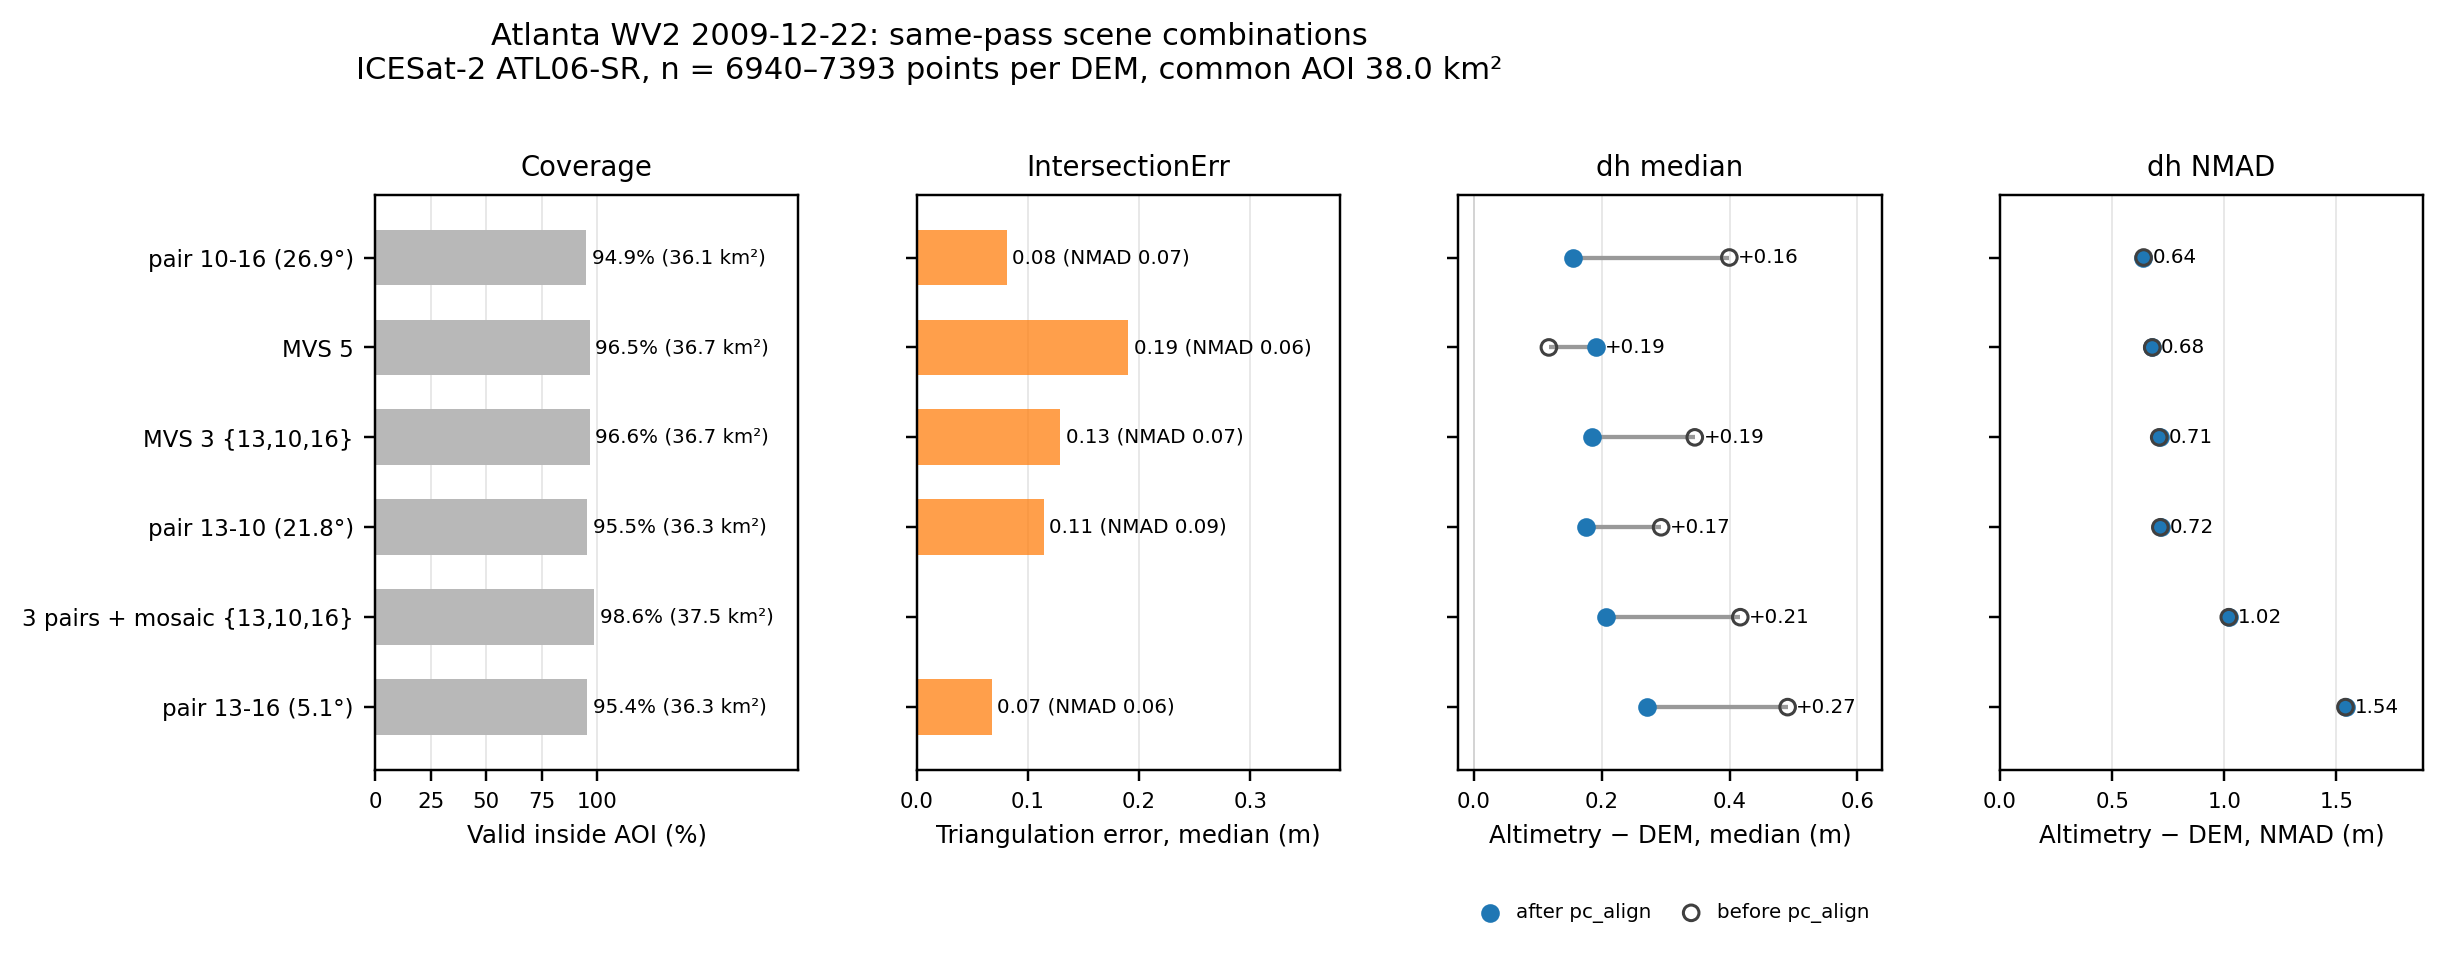

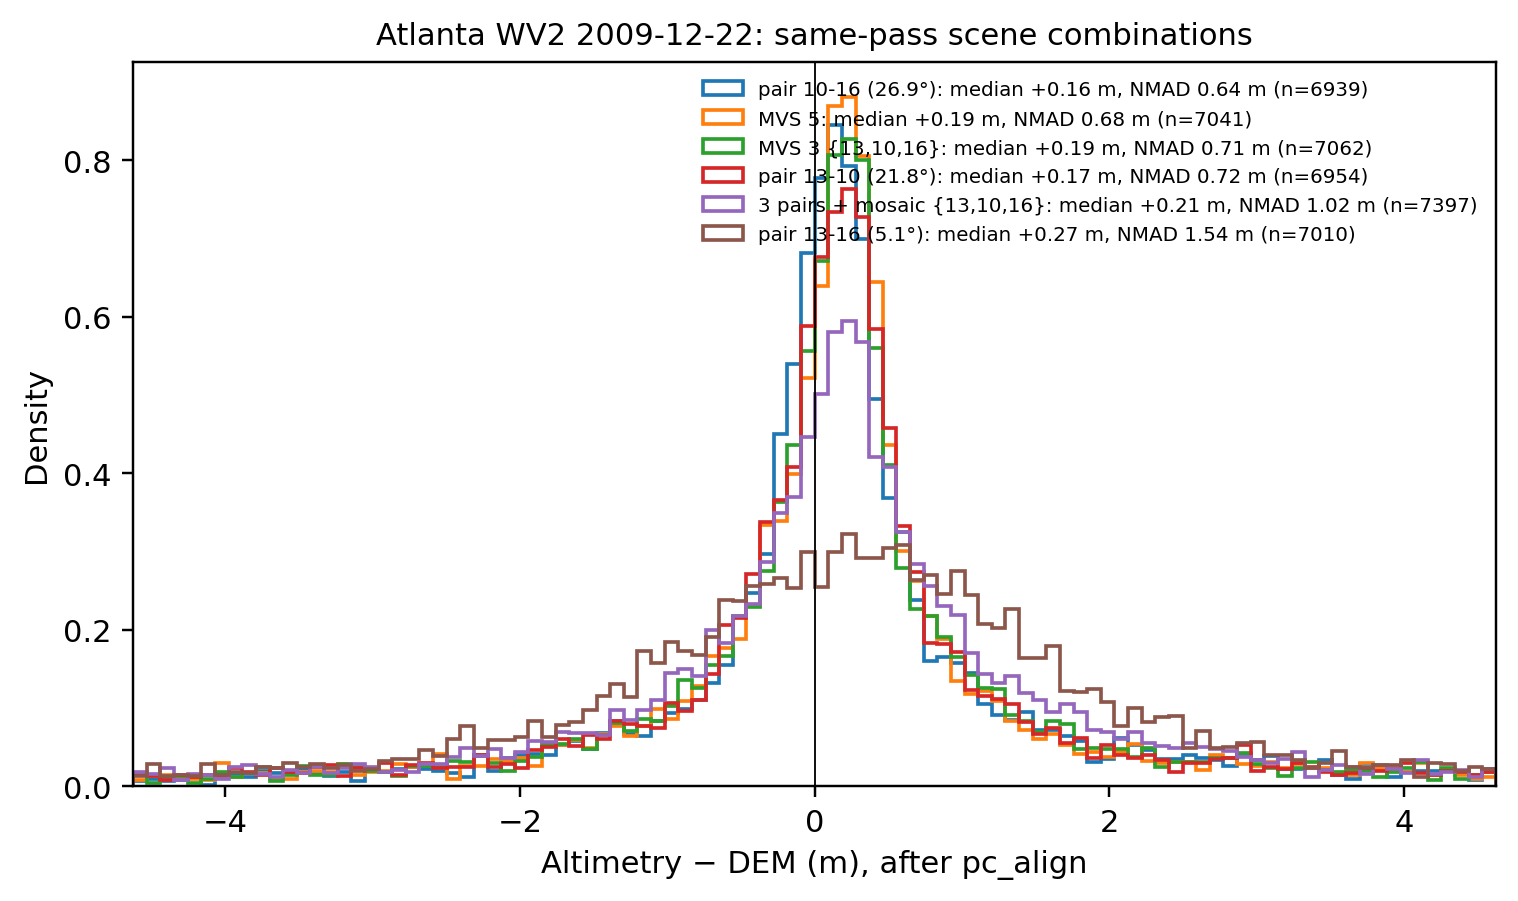

In [4]:
_ = bench.summary_plot()
_ = bench.histogram_plot()

---

## Axis 1 — single-pair accuracy vs. convergence angle

Each point is one pair, scored after its own `pc_align` translation (the translation removes bias and cannot change NMAD, so NMAD is the fair single-pair number). The 20–30° rule of thumb used in the scene-selection notebook is shaded.

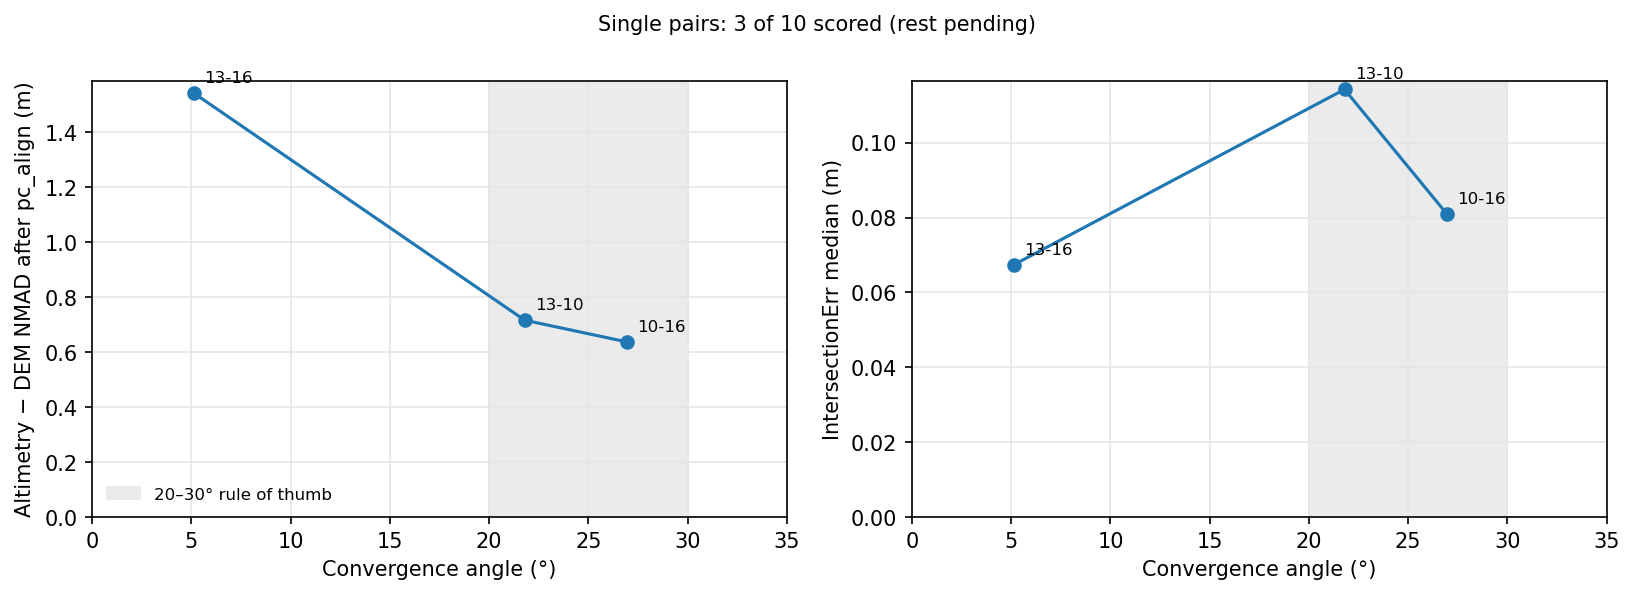

In [5]:
import matplotlib.pyplot as plt

by = stats.set_index("label")
pairs = by[by.index.str.startswith("pair ")].copy()
pairs["convergence"] = [conv_of[lbl.split()[1]] for lbl in pairs.index]
pairs = pairs.sort_values("convergence")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=150)
for ax, col, ylabel in (
    (axes[0], "dh_aligned_nmad_m", "Altimetry − DEM NMAD after pc_align (m)"),
    (axes[1], "ie_median_m", "IntersectionErr median (m)"),
):
    ax.axvspan(20, 30, color="0.92", zorder=0, label="20–30° rule of thumb")
    ax.plot(pairs["convergence"], pairs[col], "o-", color="tab:blue")
    for c, v, lbl in zip(pairs["convergence"], pairs[col], pairs.index):
        ax.annotate(lbl.split()[1], (c, v), textcoords="offset points", xytext=(5, 5), fontsize=8)
    ax.set_xlabel("Convergence angle (°)")
    ax.set_ylabel(ylabel)
    ax.set_xlim(0, 35)
    ax.set_ylim(bottom=0)
    ax.grid(color="0.9")
axes[0].legend(fontsize=8, frameon=False)
fig.suptitle(f"Single pairs: {len(pairs)} of 10 scored" + (" (rest pending)" if len(pairs) < 10 else ""), fontsize=10)
fig.tight_layout()

---

## Axis 2 — does each added scene earn its cost?

A nested chain, so each step adds exactly one scene to the previous run: pair 13-10 (21.8°) → MVS {13,10,16} → MVS {13,10,16,21} → MVS {13,10,16,21,8}. The wide-spread triple {13,8,21} is plotted alongside as a check that *which* three scenes matters, not only how many.

pending: ['MVS 4 {13,10,16,21}']


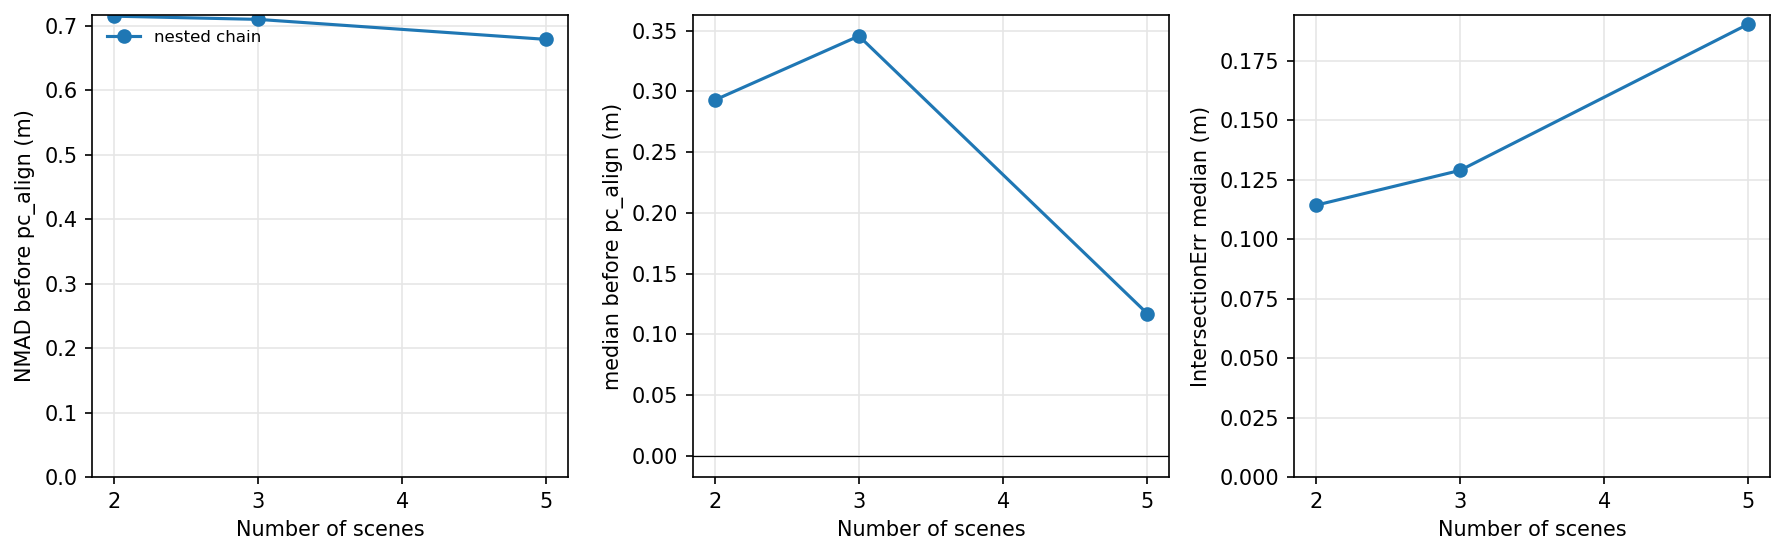

In [6]:
chain = [
    ("pair 13-10 (21.8°)", 2),
    ("MVS 3 {13,10,16}", 3),
    ("MVS 4 {13,10,16,21}", 4),
    ("MVS 5", 5),
]
present = [(lbl, n) for lbl, n in chain if lbl in by.index]
missing = [lbl for lbl, _ in chain if lbl not in by.index]
if missing:
    print("pending:", missing)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), dpi=150)
for ax, col, ylabel in (
    (axes[0], "dh_nmad_m", "NMAD before pc_align (m)"),
    (axes[1], "dh_median_m", "median before pc_align (m)"),
    (axes[2], "ie_median_m", "IntersectionErr median (m)"),
):
    ax.plot([n for _, n in present], [by.loc[lbl, col] for lbl, _ in present], "o-", color="tab:blue", label="nested chain")
    if "MVS 3 {13,8,21}" in by.index:
        ax.plot([3], [by.loc["MVS 3 {13,8,21}", col]], "s", color="tab:orange", label="MVS 3 {13,8,21}")
    ax.set_xticks([2, 3, 4, 5])
    ax.set_xlabel("Number of scenes")
    ax.set_ylabel(ylabel)
    ax.grid(color="0.9")
    if col == "dh_median_m":
        ax.axhline(0, color="k", lw=0.6)
    else:
        ax.set_ylim(bottom=0)  # spreads and errors are anchored at zero, as in summary_plot
axes[0].legend(fontsize=8, frameon=False)
fig.tight_layout()

---

## Axis 3 — joint triangulation vs. pairwise + mosaic

The same scenes processed two ways, at three and at five scenes. The five-scene pairwise flow is shown twice: every pair merged, and only the six well-converged pairs (> 15°) merged — the test of whether the mosaic's problem is *averaging* or *averaging bad pairs in*.

In [7]:
flows = [
    ("3 scenes", "MVS 3 {13,10,16}", "3 pairs + mosaic {13,10,16}"),
    ("5 scenes", "MVS 5", "10 pairs + mosaic"),
    ("5 scenes, > 15° only", "MVS 5", "6 pairs > 15° + mosaic"),
]
cols = ["valid_pct", "ie_median_m", "n_points", "dh_median_m", "dh_nmad_m", "dh_aligned_median_m", "dh_aligned_nmad_m"]
rows = []
for scenes, mvs, mosaic in flows:
    for flow, lbl in (("MVS", mvs), ("pairwise + mosaic", mosaic)):
        if lbl in by.index:
            rows.append({"scenes": scenes, "flow": flow, "DEM": lbl} | by.loc[lbl, cols].to_dict())
        else:
            rows.append({"scenes": scenes, "flow": flow, "DEM": f"{lbl} (pending)"})
pd.DataFrame(rows).set_index(["scenes", "flow"]).round(2)

DEM  \
scenes               flow                                                  
3 scenes             MVS                                MVS 3 {13,10,16}   
                     pairwise + mosaic       3 pairs + mosaic {13,10,16}   
5 scenes             MVS                                           MVS 5   
                     pairwise + mosaic       10 pairs + mosaic (pending)   
5 scenes, > 15° only MVS                                           MVS 5   
                     pairwise + mosaic  6 pairs > 15° + mosaic (pending)   

                                        valid_pct  ie_median_m  n_points  \
scenes               flow                                                  
3 scenes             MVS                    96.60         0.13    7064.0   
                     pairwise + mosaic      98.61          NaN    7393.0   
5 scenes             MVS                    96.50         0.19    7043.0   
                     pairwise + mosaic        NaN          NaN       NaN   
5 scenes, > 15° only MVS                    96.50         0.19    7043.0   
                     pairwise + mosaic        NaN          NaN       NaN   

                                        dh_median_m  dh_nmad_m  \
scenes               flow                                        
3 scenes             MVS                       0.35       0.71   
                     pairwise + mosaic         0.42       1.02   
5 scenes             MVS                       0.12       0.68   
                     pairwise + mosaic          NaN        NaN   
5 scenes, > 15° only MVS                       0.12       0.68   
                     pairwise + mosaic          NaN        NaN   

                                        dh_aligned_median_m  dh_aligned_nmad_m  
scenes               flow                                                       
3 scenes             MVS                               0.19               0.71  
                     pairwise + mosaic                 0.21               1.02  
5 scenes             MVS                               0.19               0.68  
                     pairwise + mosaic                  NaN                NaN  
5 scenes, > 15° only MVS                               0.19               0.68  
                     pairwise + mosaic                  NaN                NaN

---

## Takeaways so far (six DEMs) and what the pending runs add

With the six DEMs of the MVS example scored on one ICESat-2 sample:

- **The mosaic's problem is the weak pair.** `dem_mosaic` averages a 5.1° pair at 1.54 m NMAD with two ~0.7 m pairs and lands at 1.02 m — worse than either good pair alone. The 6-pairs-> 15° mosaic (pending) is the direct test of whether excluding weak pairs is enough to make the pairwise flow competitive.
- **Joint triangulation wins on bias, not spread.** MVS {13,10,16} matches the best single pairs on NMAD (0.71 vs. 0.64–0.72 m) and beats them on median; MVS 5 has the smallest bias of all (+0.12 m) but not the smallest NMAD (0.68 m). After `pc_align` every median lands at +0.16–0.27 m and no NMAD moves, so the ranking that survives alignment is the NMAD one.
- **IntersectionErr is not a quality ranking.** The 5.1° pair has the *lowest* triangulation error (0.07 m) and the worst DEM; five rays give MVS 5 the highest (0.19 m). Read it next to the residual panels, not alone.

What the pending runs will settle: the full shape of the NMAD-vs-convergence curve (does it keep improving past 27°, or turn over as matching degrades at 32°?), whether the nested quad sits between MVS 3 and MVS 5 or already reaches the floor, whether a wide-spread triple beats the close one, and whether the five-scene pairwise flow — with or without the weak pairs — closes the gap to joint triangulation.

An independent check exists: in [issue #156](https://github.com/uw-cryo/asp_plot/issues/156) the MVS 5 and pairwise-mosaic DEMs were also assessed against NGS survey monuments and FAA runway ends via `groundcontrol`, which ranked them the same way.